In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,accuracy_score,ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [2]:
df=pd.read_csv("osteoporosis.csv")
print(df.head())

        Id  Age  Gender         Hormone FHistory              Race  \
0  1734616   69  Female          Normal      Yes             Asian   
1  1419098   32  Female          Normal      Yes             Asian   
2  1797916   89  Female  Postmenopausal       No         Caucasian   
3  1805337   78  Female          Normal       No         Caucasian   
4  1351334   38    Male  Postmenopausal      Yes  African American   

        Weight CalciumIn   Activity Smoking          MedCondition  \
0  Underweight       Low  Sedentary     Yes  Rheumatoid Arthritis   
1  Underweight       Low  Sedentary      No                   NaN   
2       Normal  Adequate     Active      No       Hyperthyroidism   
3  Underweight  Adequate  Sedentary     Yes  Rheumatoid Arthritis   
4       Normal       Low     Active     Yes  Rheumatoid Arthritis   

       Medications Fractures  Osteoporosis  
0  Corticosteroids       Yes             1  
1              NaN       Yes             1  
2  Corticosteroids        No 

In [3]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(1958, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1958 entries, 0 to 1957
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Id            1958 non-null   int64 
 1   Age           1958 non-null   int64 
 2   Gender        1958 non-null   object
 3   Hormone       1958 non-null   object
 4   FHistory      1958 non-null   object
 5   Race          1958 non-null   object
 6   Weight        1958 non-null   object
 7   CalciumIn     1958 non-null   object
 8   Activity      1958 non-null   object
 9   Smoking       1958 non-null   object
 10  MedCondition  1311 non-null   object
 11  Medications   973 non-null    object
 12  Fractures     1958 non-null   object
 13  Osteoporosis  1958 non-null   int64 
dtypes: int64(3), object(11)
memory usage: 214.3+ KB
None
Id                0
Age               0
Gender            0
Hormone           0
FHistory          0
Race              0
Weight            0
CalciumIn   

In [4]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

In [5]:
le=LabelEncoder()
for col in df.columns:
    if df[col].dtype =='object':
        df[col]=le.fit_transform(df[col])

In [6]:
x=df.drop("Osteoporosis",axis=1)
y=df["Osteoporosis"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [7]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.fit_transform(x_test)

In [8]:
models={
    "Logistic Regression":LogisticRegression(),
    "Random Forest Classifier":RandomForestClassifier(),
    "SVM":SVC(probability=True)
}

In [9]:
accuracies={}
for name,model in models.items():
    if name == "Random Forest Classifier":
        model.fit(x_train,y_train)
        y_pred=model.predict(x_test)
    else:
        model.fit(x_train_scaled,y_train)
        y_pred=model.predict(x_test_scaled)

    acc=accuracy_score(y_test,y_pred)
    accuracies[name]=acc
print(f"{name} Accuracy: {acc:.4f}")

SVM Accuracy: 0.8342


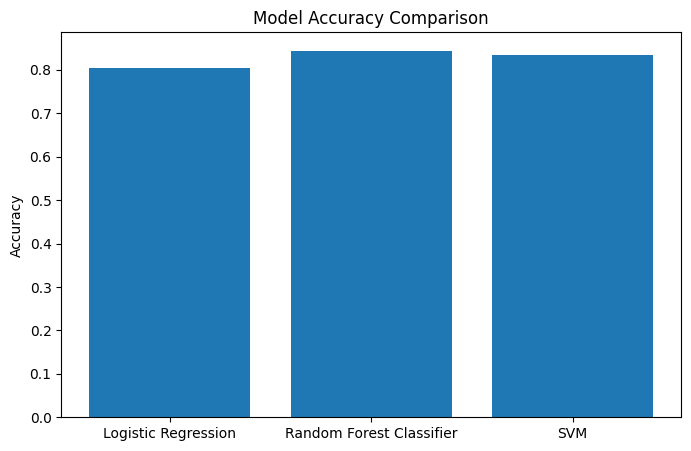

In [10]:
plt.figure(figsize=(8,5))
plt.bar(accuracies.keys(), accuracies.values())
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

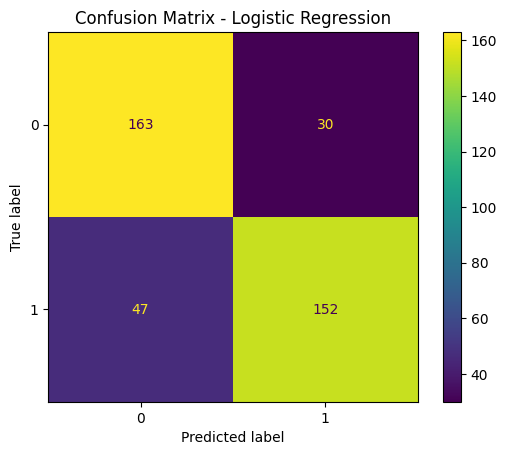

C:\Users\sukal\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


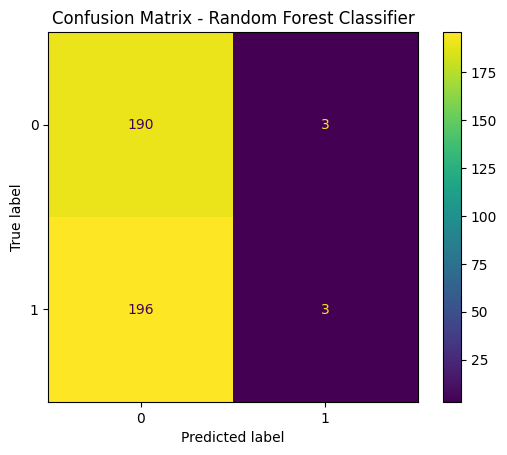

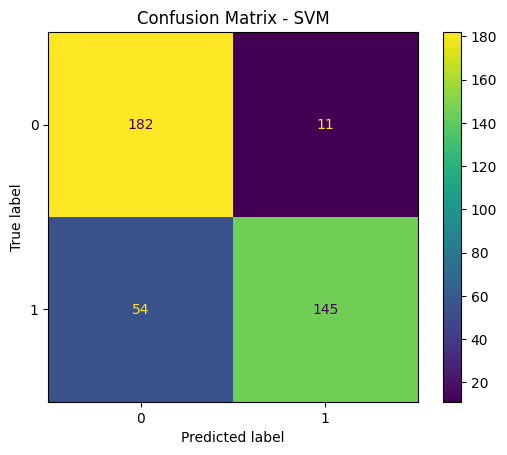

In [11]:
for name, model in models.items():
    if name == "Random Forest":
        y_pred = model.predict(x_test)
    else:
        y_pred = model.predict(x_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [12]:
best_model_name = max(accuracies, key=accuracies.get)
best_model = models[best_model_name]

print("Best Model:", best_model_name)

if best_model_name == "Random Forest":
    probs = best_model.predict_proba(x_test)[:,1]
else:
    probs = best_model.predict_proba(x_test_scaled)[:,1]

risk_profile = []

for p in probs:
    if p < 0.33:
        risk_profile.append("Low Risk")
    elif p < 0.66:
        risk_profile.append("Medium Risk")
    else:
        risk_profile.append("High Risk")


result = pd.DataFrame({
    "Actual": y_test.values,
    "Probability": probs,
    "Risk Level": risk_profile
})

print(result.head(10))

Best Model: Random Forest Classifier
   Actual  Probability   Risk Level
0       0         0.30     Low Risk
1       1         0.29     Low Risk
2       1         0.44  Medium Risk
3       1         0.21     Low Risk
4       0         0.30     Low Risk
5       1         0.36  Medium Risk
6       1         0.31     Low Risk
7       0         0.20     Low Risk
8       1         0.39  Medium Risk
9       1         0.30     Low Risk


C:\Users\sukal\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
